In [1]:
from langgraph.graph import StateGraph,START,END
from langchain_mistralai import ChatMistralAI
from dotenv import load_dotenv
from IPython.display import Markdown,display
from pydantic import BaseModel


In [2]:
load_dotenv(override=True)

True

In [3]:
llm=ChatMistralAI(
    model="open-mistral-7b"
)

In [4]:
result=llm.invoke("hi hello")

In [7]:
print(result.content)

Hello! 😊 How can I help you today? Whether you have a question, need advice, or just want to chat—I'm here for it! What's on your mind?


In [9]:
class state(BaseModel):
    CV:str
    job_discription:str
    strengths:str
    weekness:str
    interview_questions:str
    screen_report:str

In [10]:
def strength_node(state:state):
    prompt=f"""Analyze the candidate's strengths based on the CV and job description.

CV:
{state.CV}

Job Description:
{state.job_discription}

Give 3 short strengths."""
    response=llm.invoke(prompt)
    return {"strengths":response.content}

In [34]:
def weaknesses_node(state: state):
    prompt = f"""
Analyze the candidate's weaknesses or skill gaps based on the CV
and job description.

CV:
{state.CV}

Job Description:
{state.job_discription}

Give 3 short weaknesses or gaps.
"""

    response = llm.invoke(prompt)

    return {"weekness": response.content}

In [20]:
def interview_questions_node(state: state):
    prompt = f"""
Create 5 interview questions for this candidate based on the CV
and job description.

CV:
{state.CV}

Job Description:
{state.job_discription}
"""

    response = llm.invoke(prompt)

    return {"interview_questions": response.content}

In [35]:
def final_report_node(state: state):
    prompt = f"""
Create a short candidate screening report.

Strengths:
{state.strengths}

Weaknesses:
{state.weekness}

Interview Questions:
{state.interview_questions}

Give the final report with:
1. Strengths
2. Weaknesses
3. Interview Questions
4. Overall Recommendation
"""

    response = llm.invoke(prompt)

    return {"screen_report": response.content}

In [42]:
graph_builder=StateGraph(state)

In [43]:
graph_builder.add_node("strength_node",strength_node)
graph_builder.add_node("weaknesses_node",weaknesses_node)
graph_builder.add_node("interview_questions_node",interview_questions_node)
graph_builder.add_node("final_report_node",final_report_node)

In [44]:
graph_builder.add_edge(START,"strength_node")
graph_builder.add_edge(START,"weaknesses_node")
graph_builder.add_edge(START,"interview_questions_node")
graph_builder.add_edge("strength_node","final_report_node")
graph_builder.add_edge("weaknesses_node","final_report_node")
graph_builder.add_edge("interview_questions_node","final_report_node")
graph_builder.add_edge("final_report_node",END)

In [45]:
graph=graph_builder.compile()

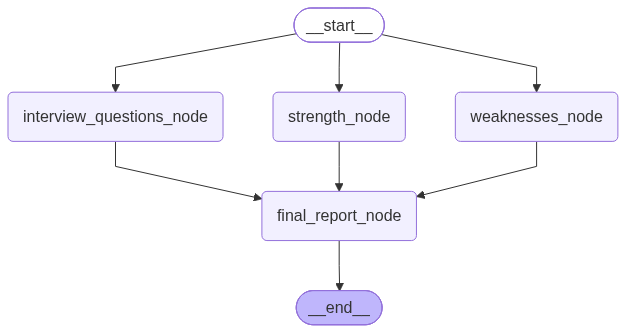

In [26]:
graph

In [15]:
cv_text = """
Name: Ali Khan
Role: Python Developer

Skills:
Python, LangChain, LangGraph, REST APIs, Git, SQL

Experience:
2 years of experience building Python applications and AI tools.

Projects:
Built a chatbot using LangChain.
Created an AI workflow using LangGraph.
Developed REST APIs using Python.
"""


# Demo Job Description
job_description = """
Job Title: AI/LLM Developer

Requirements:
- Strong Python skills
- Experience with LangChain or LangGraph
- Knowledge of REST APIs
- Understanding of AI/LLM workflows
- Git and SQL knowledge

Experience:
1-3 years of software or AI development experience.
"""

In [16]:
initial_state=state(CV=cv_text,job_discription=job_description,strengths="",weekness="",interview_questions="",screen_report="")

In [46]:
result=graph.invoke(initial_state)

In [47]:
display(Markdown(result["strengths"]))

Here are **three key strengths** of **Ali Khan** based on the CV and job description:

1. **Direct Alignment with AI/LLM Tools** – Strong experience with **LangChain** (built a chatbot) and **LangGraph** (created AI workflows), directly matching the job’s core requirements for AI/LLM development.

2. **Full-Stack Python & API Proficiency** – Combines **Python development**, **REST API creation**, and **AI tool integration**, demonstrating versatility in both backend logic and AI workflows.

3. **Relevant Technical Stack** – Meets all listed requirements (Python, LangChain/LangGraph, REST APIs, Git, SQL) with **2 years of hands-on experience**, fitting the 1–3 years of AI/software development needed.

In [48]:
display(Markdown(result["weekness"]))

Here are **three key weaknesses or skill gaps** in Ali Khan’s CV relative to the **AI/LLM Developer** job description:

1. **Limited Depth in AI/ML Foundations**
   - The CV mentions AI tools (LangChain, LangGraph) but lacks explicit mention of core AI/ML concepts (e.g., NLP techniques, model training, fine-tuning, or evaluation metrics). The job likely expects broader AI knowledge beyond just framework usage.

2. **No Mention of Cloud/AI Infrastructure**
   - The role may require familiarity with cloud platforms (AWS/GCP/Azure) for deploying AI models or scaling workflows. Ali’s CV doesn’t highlight experience with cloud services, APIs (e.g., OpenAI, Hugging Face), or deployment tools (Docker, FastAPI).

3. **Short Experience Duration**
   - While within the 1–3 years range, **2 years** is on the lower end for an AI/LLM role, which often demands deeper expertise. The CV could strengthen by emphasizing **impact** (e.g., performance improvements, scalability) or **advanced projects** (e.g., custom LLM fine-tuning) to justify experience level.

---
**Bonus Observation:**
- **SQL** is listed but not tied to AI-specific use cases (e.g., querying LLM-generated data). Clarifying how SQL was used in AI projects (e.g., storing embeddings, analyzing metrics) would add value.

In [49]:
display(Markdown(result["interview_questions"]))

Here are **5 tailored interview questions** for **Ali Khan** based on his CV and the **AI/LLM Developer** job description:

---

### **1. Python & AI Workflow Expertise**
*"You’ve built a chatbot using **LangChain** and an AI workflow with **LangGraph**. Can you walk us through the key design choices you made when integrating these tools? How did you ensure scalability and maintainability in your workflow?"*
*(Assesses: Python expertise, LangChain/LangGraph knowledge, and AI workflow design.)*

---

### **2. REST API Development**
*"You’ve developed REST APIs in Python. A common challenge is balancing performance and security. Can you share an example where you optimized an API (e.g., reduced latency, improved security)? How did you handle versioning or backward compatibility?"*
*(Assesses: REST API knowledge, problem-solving, and best practices.)*

---

### **3. Git & Collaboration**
*"You mention experience with **Git**. Describe a time when you worked on a team project where merge conflicts or branching strategies caused issues. How did you resolve them, and what lessons did you learn?"*
*(Assesses: Git proficiency, teamwork, and debugging skills.)*

---

### **4. SQL & Data Integration**
*"The role requires **SQL knowledge**. Have you used SQL in your projects? Can you give an example where you queried or optimized a database to support an AI application (e.g., fetching user data for a chatbot)?"*
*(Assesses: SQL skills, data handling for AI, and practical application.)*

---

### **5. AI/ML & Future Challenges**
*"Given your experience with **LangChain/LangGraph**, how would you approach building a **custom LLM pipeline** for a business use case (e.g., a customer support chatbot)? What tools or techniques would you prioritize, and how would you evaluate its success?"*
*(Assesses: AI/ML thinking, problem-solving, and alignment with job requirements.)*

---
### **Why These Questions?**
- **Directly tied to CV & JD** (Python, LangChain, APIs, Git, SQL, AI workflows).
- **Behavioral + technical balance** (e.g., Git conflict resolution, API optimization).
- **Future-focused** (e.g., custom LLM pipeline design).

Would you like any adjustments based on specific priorities (e.g., more focus on LangGraph or SQL)?

In [50]:
display(Markdown(result["screen_report"]))

### **Candidate Screening Report: Ali Khan**
**Role:** AI/LLM Developer
**Experience Level:** 2 years (1–3 years target)

---

### **1. Strengths**
✅ **Direct Alignment with AI/LLM Tools** – Strong hands-on experience with **LangChain** (built a production-ready chatbot) and **LangGraph** (designed AI workflows), directly matching core job requirements. Demonstrates practical, not just theoretical, expertise.

✅ **Full-Stack Python & API Proficiency** – Combines **Python development**, **REST API creation**, and **AI tool integration**, showing versatility in backend logic, data pipelines, and AI workflows. Skills are immediately applicable to building scalable AI systems.

✅ **Technical Stack Fit** – Meets **all listed requirements** (Python, LangChain/LangGraph, REST APIs, Git, SQL) with **2 years of relevant experience**. Experience duration aligns with the job’s 1–3 years target, though depth could be deeper.

---

### **2. Weaknesses & Skill Gaps**
⚠ **Lack of AI/ML Foundations** – CV focuses on **tool usage** (LangChain, LangGraph) but lacks explicit mention of:
   - Core NLP techniques (e.g., tokenization, embeddings, fine-tuning).
   - Model evaluation metrics (e.g., BLEU, perplexity, RAG accuracy).
   - **Impact:** May struggle with advanced AI tasks (e.g., custom model training, hyperparameter tuning) beyond framework-based solutions.

⚠ **No Cloud/AI Infrastructure Experience** – Missing:
   - Cloud platforms (AWS/GCP/Azure) for **model deployment/scaling**.
   - APIs (OpenAI, Hugging Face) or **MLOps tools** (Docker, FastAPI).
   - **Impact:** Could be a bottleneck for roles requiring cloud-native AI pipelines or production-grade deployments.

⚠ **Short Experience Duration** – While within range, **2 years is lean** for AI/LLM roles, which often demand:
   - **Deeper project examples** (e.g., fine-tuning LLMs, optimizing RAG systems).
   - **Quantifiable impact** (e.g., "Reduced chatbot latency by X%").
   - **Advanced topics** (e.g., prompt engineering, multi-modal models).
   - **Impact:** May need mentorship or time to ramp up on foundational AI concepts.

---
### **3. Interview Questions**
*(Balanced technical + behavioral, tied to CV and JD)*

#### **Technical Deep Dive**
1. **LangChain/LangGraph Design**
   *"Your chatbot used LangChain. How did you handle **context window limits** or **hallucinations**? If you were to redesign it today, what improvements would you make?"*
   *(Assesses: Debugging, prompt engineering, and iterative improvement.)*

2. **API & Scalability**
   *"You built REST APIs. How would you optimize an AI endpoint for **low-latency responses** (e.g., caching, async processing) if it were serving 10K+ requests/day?"*
   *(Assesses: Performance tuning, trade-offs between speed/accuracy.)*

3. **SQL for AI**
   *"Describe a time you used SQL to **analyze or store AI-generated data** (e.g., embeddings, user feedback). How did you ensure data integrity?"*
   *(Assesses: Practical SQL-AI integration, not just generic queries.)*

4. **Custom LLM Pipeline**
   *"If tasked with building a **domain-specific LLM** (e.g., healthcare chatbot), what steps would you take beyond LangChain? How would you evaluate its performance?"*
   *(Assesses: End-to-end AI pipeline design, not just tool chaining.)*

#### **Behavioral & Cultural Fit**
5. **Collaboration & Problem-Solving**
   *"Share a time you faced a **technical block** in an AI project. How did you diagnose and resolve it?"*
   *(Assesses: Debugging mindset, resourcefulness.)*

6. **Learning Agility**
   *"AI evolves rapidly. How do you stay updated on new tools (e.g., new LangChain features, model architectures)?"*
   *(Assesses: Proactivity and growth mindset.)*

---
### **4. Overall Recommendation**
**Proceed to Interview with Caution**
- **Strengths:** Strong **hands-on AI tool experience** (LangChain/LangGraph) and **full-stack Python skills** make Ali a **solid candidate for junior-to-mid-level AI roles** where framework usage is prioritized over deep AI research.
- **Gaps to Probe:**
  - **AI fundamentals:** Ask about NLP techniques, model evaluation, or fine-tuning to gauge depth.
  - **Cloud/AI ops:** Clarify if they’ve deployed models or worked with APIs (e.g., OpenAI) outside LangChain.
  - **Impact:** Push for **quantifiable results** (e.g., "How did your chatbot improve user satisfaction?").
- **Best Fit:**
  - **Ideal for:** Roles where **LangChain/LangGraph + Python APIs** are core, and **mentorship** is available for AI foundations.
  - **Avoid for:** Highly specialized AI research, MLOps-heavy, or cloud-native AI teams without onboarding.
- **Development Plan:**
  - If hired, pair with a **senior AI engineer** to fill gaps in **model training, cloud deployment, and evaluation metrics**.
  - Encourage **side projects** (e.g., fine-tuning a small LLM, building a RAG system) to demonstrate growth.

---
### **Final Note**
Ali shows **promise for AI tool-based development** but would benefit from **structured upskilling** in AI fundamentals and cloud/AI ops. A **progressive onboarding path** is recommended.

**Next Steps:**
- Schedule interview focusing on **technical depth (Q1–Q4)** and **problem-solving (Q5–Q6)**.
- Prepare to **mentor** on AI theory and deployment best practices.